# Домашнее задание №4. Data Understanding и формирование датасета

**Проект:** Hotel Booking Cancellation Risk.  
**Задача:** подготовить датасет для бинарной классификации отмен бронирований и доказать, что выводы основаны на фактическом EDA, а не только на текстовом описании.

Этот ноутбук закрывает замечание проверяющего: здесь есть исполняемый код, таблицы, визуализации, проверка качества данных, leakage audit, формирование итоговых CSV и стратегия валидации.

Главная продуктовая логика из предыдущих ДЗ сохраняется:

```text
данные бронирования → честный прогноз отмены → приоритизация риска → управленческое действие → оценка денег
```

Для ДЗ №4 фокус не на финальной модели, а на корректном датасете: какие данные берем, что чистим, какие признаки считаем допустимыми, как делим выборку и какие риски качества фиксируем.

## 0. Соответствие требованиям задания

| Требование ДЗ №4 | Где реализовано в ноутбуке |
|---|---|
| Источник и состав данных | разделы 1–2: загрузка, схема, размеры, периоды, целевая переменная |
| Базовый EDA с выводами для моделирования | раздел 3: target, пропуски, выбросы, сегменты, lead time, сезонность, выручка |
| Оценка качества разметки | раздел 5: `is_canceled`, `reservation_status`, неоднозначность Canceled/No-Show |
| Алгоритм формирования выборки | раздел 6: cleaning, feature engineering, итоговые CSV |
| Стратегия валидации | раздел 7: time-based split, external validation, запрет leakage |

In [27]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Универсальное определение корня проекта:
# работает и при запуске из notebooks/, и при запуске из корня репозитория.
CWD = Path.cwd()
if (CWD / 'data').exists():
    ROOT = CWD
elif (CWD.parent / 'data').exists():
    ROOT = CWD.parent
else:
    ROOT = Path('..').resolve()

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures' / 'hw4_eda'
TABLES = REPORTS / 'tables'

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

MAIN_PATH = DATA_RAW / 'hotel_bookings.csv'
EXTRA_PATH = DATA_RAW / 'Hotel Reservations.csv'

print('ROOT:', ROOT)
print('MAIN_PATH exists:', MAIN_PATH.exists(), MAIN_PATH)
print('EXTRA_PATH exists:', EXTRA_PATH.exists(), EXTRA_PATH)

ROOT: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk
MAIN_PATH exists: True /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/data/raw/hotel_bookings.csv
EXTRA_PATH exists: True /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/data/raw/Hotel Reservations.csv


In [28]:
def savefig(name: str):
    """Сохраняет текущую matplotlib-фигуру в reports/figures/hw4_eda."""
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches='tight')
    print(f'Saved: {path.relative_to(ROOT)}')


def rate_table(df: pd.DataFrame, group_col: str, target: str = 'is_canceled', min_count: int = 1) -> pd.DataFrame:
    out = (
        df.groupby(group_col, dropna=False)[target]
          .agg(count='size', cancellations='sum', cancel_rate='mean')
          .reset_index()
    )
    out = out[out['count'] >= min_count].copy()
    out['share_of_rows'] = out['count'] / len(df)
    return out.sort_values(['cancel_rate', 'count'], ascending=[False, False])


def pct(x):
    return f'{100*x:.2f}%'

## 1. Источники и состав данных

Используются два публичных датасета.

1. **Hotel Booking Demand Dataset** (`hotel_bookings.csv`) — основной датасет. Он богаче по продуктовым признакам: тип отеля, канал, сегмент, депозит, страна, агент, ADR, специальные запросы. Используется как основной modeling dataset.
2. **Hotel Reservations Classification Dataset** (`Hotel Reservations.csv`) — дополнительный датасет. Он имеет более узкую схему и используется не для слепого объединения, а как external validation / проверка переносимости закономерностей.

Критически важно: дополнительный датасет имеет другую схему и частично другую семантику метки, поэтому он не должен механически смешиваться с основным без поля `source_dataset` и без domain-aware validation.

In [29]:
main_raw = pd.read_csv(MAIN_PATH)
extra_raw = pd.read_csv(EXTRA_PATH)

summary = pd.DataFrame([
    {
        'dataset': 'main: hotel_bookings.csv',
        'rows': len(main_raw),
        'columns': main_raw.shape[1],
        'target_column': 'is_canceled',
        'positive_class_rate': main_raw['is_canceled'].mean(),
    },
    {
        'dataset': 'additional: Hotel Reservations.csv',
        'rows': len(extra_raw),
        'columns': extra_raw.shape[1],
        'target_column': 'booking_status == Canceled',
        'positive_class_rate': extra_raw['booking_status'].eq('Canceled').mean(),
    }
])
summary.to_csv(TABLES / 'hw4_source_datasets_summary.csv', index=False)
display(summary)

,dataset,rows,columns,target_column,positive_class_rate
0,main: hotel_bookings.csv,119390,32,is_canceled,0.3704
1,additional: Hotel Reservations.csv,36275,19,booking_status == Canceled,0.3276


In [30]:
display(Markdown('### Основной датасет: первые строки'))
display(main_raw.head(5))

display(Markdown('### Типы колонок основного датасета'))
schema_main = pd.DataFrame({
    'column': main_raw.columns,
    'dtype': [str(main_raw[c].dtype) for c in main_raw.columns],
    'missing_count': [int(main_raw[c].isna().sum()) for c in main_raw.columns],
    'missing_rate': [main_raw[c].isna().mean() for c in main_raw.columns],
    'n_unique': [main_raw[c].nunique(dropna=False) for c in main_raw.columns],
})
schema_main.to_csv(TABLES / 'hw4_main_raw_schema.csv', index=False)
display(schema_main)

### Основной датасет: первые строки

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0000,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0000,NaN,0,Transient,98.0000,0,1,Check-Out,2015-07-03


### Типы колонок основного датасета

,column,dtype,missing_count,missing_rate,n_unique
0,hotel,str,0,0.0000,2
1,is_canceled,int64,0,0.0000,2
2,lead_time,int64,0,0.0000,479
3,arrival_date_year,int64,0,0.0000,3
4,arrival_date_month,str,0,0.0000,12
5,arrival_date_week_number,int64,0,0.0000,53
6,arrival_date_day_of_month,int64,0,0.0000,31
7,stays_in_weekend_nights,int64,0,0.0000,17
8,stays_in_week_nights,int64,0,0.0000,35
9,adults,int64,0,0.0000,14


In [31]:
display(Markdown('### Дополнительный датасет: первые строки'))
display(extra_raw.head(5))

display(Markdown('### Типы колонок дополнительного датасета'))
schema_extra = pd.DataFrame({
    'column': extra_raw.columns,
    'dtype': [str(extra_raw[c].dtype) for c in extra_raw.columns],
    'missing_count': [int(extra_raw[c].isna().sum()) for c in extra_raw.columns],
    'missing_rate': [extra_raw[c].isna().mean() for c in extra_raw.columns],
    'n_unique': [extra_raw[c].nunique(dropna=False) for c in extra_raw.columns],
})
schema_extra.to_csv(TABLES / 'hw4_additional_raw_schema.csv', index=False)
display(schema_extra)

### Дополнительный датасет: первые строки

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.0000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.6800,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.0000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.0000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.5000,0,Canceled


### Типы колонок дополнительного датасета

,column,dtype,missing_count,missing_rate,n_unique
0,Booking_ID,str,0,0.0000,36275
1,no_of_adults,int64,0,0.0000,5
2,no_of_children,int64,0,0.0000,6
3,no_of_weekend_nights,int64,0,0.0000,8
4,no_of_week_nights,int64,0,0.0000,18
5,type_of_meal_plan,str,0,0.0000,4
6,required_car_parking_space,int64,0,0.0000,2
7,room_type_reserved,str,0,0.0000,7
8,lead_time,int64,0,0.0000,352
9,arrival_year,int64,0,0.0000,2


## 2. Подготовка служебных дат и производных признаков для EDA

В датасете нет явной даты создания бронирования. Для временной валидации восстанавливаем ее приближенно:

```text
booking_creation_date = arrival_date - lead_time
```

Это не идеальная operational timestamp, но для учебного проекта это более честно, чем случайный split, потому что прогноз отмен должен проверяться на будущих бронированиях, а не на случайно перемешанных строках.

In [32]:
MONTHS = {m: i for i, m in enumerate([
    'January','February','March','April','May','June','July','August','September','October','November','December'
], 1)}
MONTHS_REV = {v: k for k, v in MONTHS.items()}


def season(month: int) -> str:
    if month in [12, 1, 2]:
        return 'winter'
    if month in [3, 4, 5]:
        return 'spring'
    if month in [6, 7, 8]:
        return 'summer'
    return 'autumn'

main_eda = main_raw.copy()
main_eda['children'] = main_eda['children'].fillna(0)
main_eda['arrival_month_num'] = main_eda['arrival_date_month'].map(MONTHS)
main_eda['arrival_date'] = pd.to_datetime(dict(
    year=main_eda['arrival_date_year'],
    month=main_eda['arrival_month_num'],
    day=main_eda['arrival_date_day_of_month'],
), errors='coerce')
main_eda['booking_creation_date'] = main_eda['arrival_date'] - pd.to_timedelta(main_eda['lead_time'], unit='D')
main_eda['total_nights'] = main_eda['stays_in_weekend_nights'] + main_eda['stays_in_week_nights']
main_eda['total_guests'] = main_eda['adults'] + main_eda['children'] + main_eda['babies']
main_eda['booking_value'] = main_eda['adr'] * main_eda['total_nights']
main_eda['has_children'] = ((main_eda['children'] + main_eda['babies']) > 0).astype(int)
main_eda['has_previous_cancellations'] = (main_eda['previous_cancellations'] > 0).astype(int)
main_eda['has_special_requests'] = (main_eda['total_of_special_requests'] > 0).astype(int)
main_eda['is_long_lead_booking'] = (main_eda['lead_time'] > 90).astype(int)
main_eda['lead_time_bin'] = pd.cut(
    main_eda['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+']
)
main_eda['adr_bin'] = pd.qcut(main_eda['adr'].clip(lower=0, upper=500), q=5, duplicates='drop')
main_eda['arrival_season'] = main_eda['arrival_month_num'].map(season)

periods = pd.DataFrame([
    {'field': 'arrival_date', 'min': main_eda['arrival_date'].min(), 'max': main_eda['arrival_date'].max()},
    {'field': 'booking_creation_date', 'min': main_eda['booking_creation_date'].min(), 'max': main_eda['booking_creation_date'].max()},
])
display(periods)

,field,min,max
0,arrival_date,2015-07-01,2017-08-31
1,booking_creation_date,2013-06-24,2017-08-31


## 3. Базовый EDA: фактура анализа

Далее идут графики и таблицы, на основании которых сформированы выводы для моделирования. Главные вопросы EDA:

- есть ли дисбаланс целевой переменной;
- какие признаки дают сильные различия в отменах;
- есть ли пропуски и некорректные строки;
- какие признаки опасны с точки зрения утечки;
- как лучше формировать train/validation/test.

### 3.1. Распределение целевой переменной

,is_canceled,count,share
0,0,75166,0.6296
1,1,44224,0.3704


Saved: reports/figures/hw4_eda/hw4_target_distribution.png


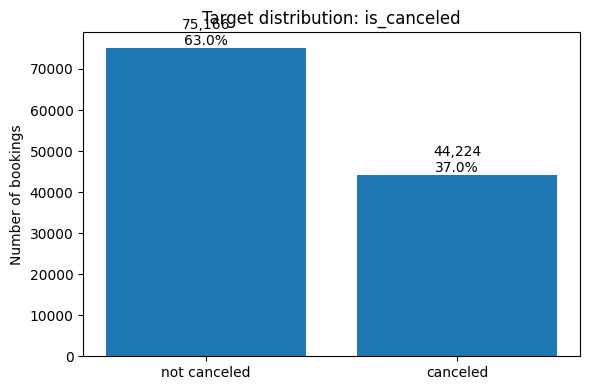

In [33]:
target_counts = main_eda['is_canceled'].value_counts().sort_index()
target_summary = pd.DataFrame({
    'is_canceled': target_counts.index,
    'count': target_counts.values,
    'share': target_counts.values / len(main_eda),
})
target_summary.to_csv(TABLES / 'hw4_target_distribution.csv', index=False)
display(target_summary)

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['not canceled', 'canceled']
ax.bar(labels, target_counts.values)
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f'{v:,}\n{v/len(main_eda):.1%}', ha='center', va='bottom')
ax.set_title('Target distribution: is_canceled')
ax.set_ylabel('Number of bookings')
savefig('hw4_target_distribution.png')
plt.show()

**Вывод для моделирования.** Доля отмен около 37%, то есть это не экстремальный дисбаланс 1:100, но accuracy все равно нельзя делать основной метрикой. Для продукта важнее ранжировать верхние 10–20% рискованных бронирований, поэтому на следующих этапах нужны ROC-AUC, PR-AUC, Recall/Precision по классу отмен и Precision@K/Lift@K.

### 3.2. Пропуски и полнота данных

,column,missing_count,missing_rate
24,company,112593,0.9431
23,agent,16340,0.1369
13,country,488,0.0041
10,children,4,0.0000


Saved: reports/figures/hw4_eda/hw4_missing_values.png


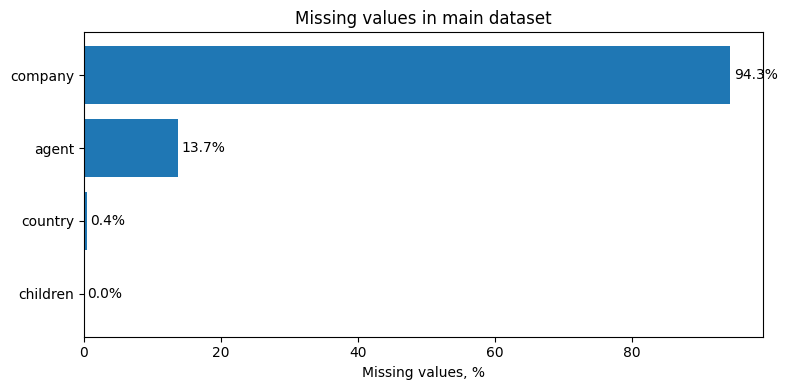

In [34]:
missing = (
    main_raw.isna().sum()
    .rename('missing_count')
    .reset_index()
    .rename(columns={'index': 'column'})
)
missing['missing_rate'] = missing['missing_count'] / len(main_raw)
missing = missing.sort_values('missing_count', ascending=False)
missing.to_csv(TABLES / 'hw4_missing_values.csv', index=False)
display(missing[missing['missing_count'] > 0])

plot_missing = missing[missing['missing_count'] > 0].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_missing['column'][::-1], plot_missing['missing_rate'][::-1] * 100)
ax.set_xlabel('Missing values, %')
ax.set_title('Missing values in main dataset')
for i, v in enumerate((plot_missing['missing_rate'][::-1] * 100)):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
savefig('hw4_missing_values.png')
plt.show()

**Вывод для моделирования.** `company` почти полностью пустой, поэтому использовать его как категориальный ID нельзя; оставляем только бинарный признак `has_company`. `agent` имеет существенную долю пропусков, поэтому используем `agent_missing` и заполняем неизвестного агента отдельной категорией. `country` и `children` заполняются безопасно: `country='Unknown'`, `children=0`.

### 3.3. Некорректные строки, выбросы и санитарные проверки

In [35]:
quality_checks = pd.DataFrame([
    {'check': 'arrival_date is missing', 'count': int(main_eda['arrival_date'].isna().sum())},
    {'check': 'total_guests == 0', 'count': int((main_eda['total_guests'] == 0).sum())},
    {'check': 'total_nights == 0', 'count': int((main_eda['total_nights'] == 0).sum())},
    {'check': 'adr < 0', 'count': int((main_eda['adr'] < 0).sum())},
    {'check': 'lead_time < 0', 'count': int((main_eda['lead_time'] < 0).sum())},
    {'check': 'booking_value < 0', 'count': int((main_eda['booking_value'] < 0).sum())},
])
quality_checks['share'] = quality_checks['count'] / len(main_eda)
quality_checks.to_csv(TABLES / 'hw4_quality_checks.csv', index=False)
display(quality_checks)

numeric_summary = main_eda[['lead_time', 'adr', 'total_nights', 'total_guests', 'booking_value']].describe(percentiles=[.01, .05, .5, .95, .99]).T
numeric_summary.to_csv(TABLES / 'hw4_numeric_summary.csv')
display(numeric_summary)

,check,count,share
0,arrival_date is missing,0,0.0000
1,total_guests == 0,180,0.0015
2,total_nights == 0,715,0.0060
3,adr < 0,1,0.0000
4,lead_time < 0,0,0.0000
5,booking_value < 0,1,0.0000


,count,mean,std,min,1%,5%,50%,95%,99%,max
lead_time,"119,390.0000",104.0114,106.8631,0.0000,0.0000,0.0000,69.0000,320.0000,444.0000,737.0000
adr,"119,390.0000",101.8311,50.5358,-6.3800,0.0000,38.4000,94.5750,193.5000,252.0000,"5,400.0000"
total_nights,"119,390.0000",3.4279,2.5574,0.0000,1.0000,1.0000,3.0000,7.0000,14.0000,69.0000
total_guests,"119,390.0000",1.9682,0.7224,0.0000,1.0000,1.0000,2.0000,3.0000,4.0000,55.0000
booking_value,"119,390.0000",357.8482,335.9101,-63.8000,0.0000,56.9635,267.0000,"1,001.1970","1,680.0000","7,590.0000"


Saved: reports/figures/hw4_eda/hw4_numeric_distributions.png


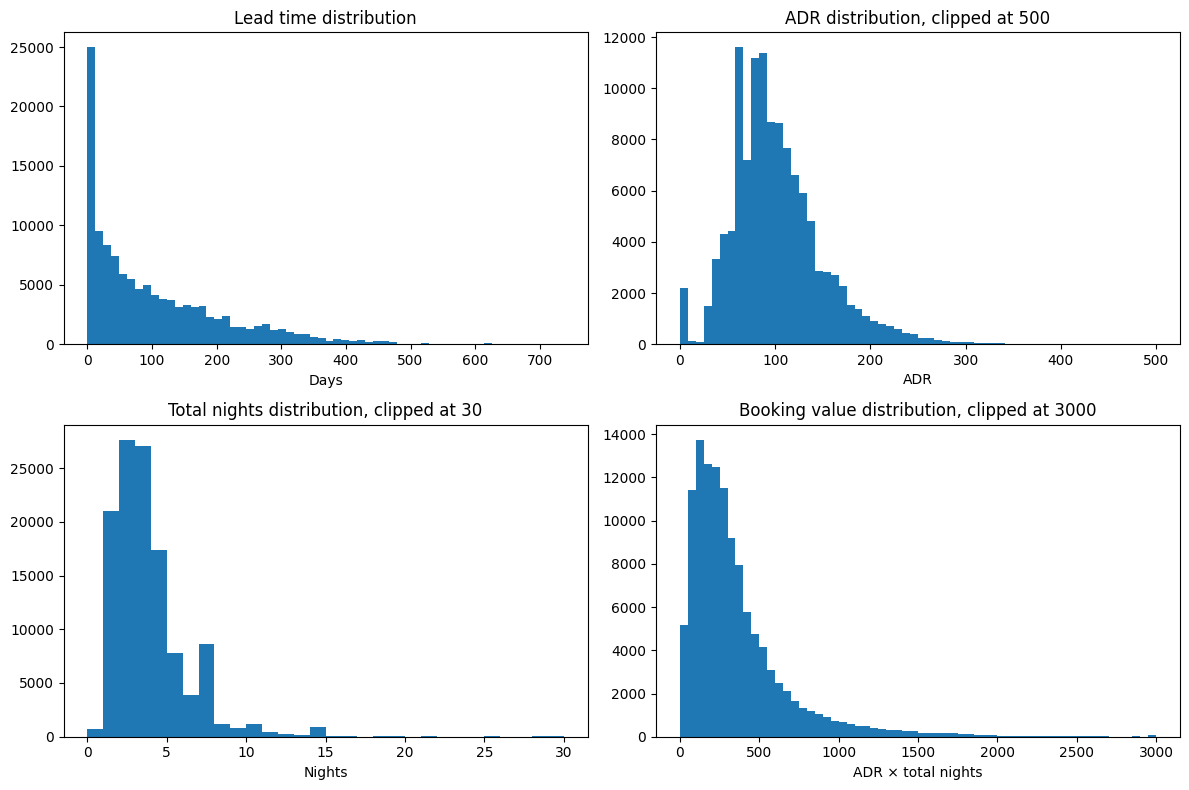

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(main_eda['lead_time'], bins=60)
axes[0,0].set_title('Lead time distribution')
axes[0,0].set_xlabel('Days')

axes[0,1].hist(main_eda['adr'].clip(lower=0, upper=500), bins=60)
axes[0,1].set_title('ADR distribution, clipped at 500')
axes[0,1].set_xlabel('ADR')

axes[1,0].hist(main_eda['total_nights'].clip(upper=30), bins=30)
axes[1,0].set_title('Total nights distribution, clipped at 30')
axes[1,0].set_xlabel('Nights')

axes[1,1].hist(main_eda['booking_value'].clip(lower=0, upper=3000), bins=60)
axes[1,1].set_title('Booking value distribution, clipped at 3000')
axes[1,1].set_xlabel('ADR × total nights')

savefig('hw4_numeric_distributions.png')
plt.show()

**Решение для датасета.** Удаляем строки без гостей, без ночей, с отрицательным ADR и с некорректной датой. Это небольшая доля данных, зато итоговый датасет становится корректнее для расчета `booking_value = adr × total_nights` и для бизнес-симуляции.

### 3.4. Тип отеля, сегменты и каналы

#### Cancellation rate by `hotel`

,hotel,count,cancellations,cancel_rate,share_of_rows
0,City Hotel,79330,33102,0.4173,0.6645
1,Resort Hotel,40060,11122,0.2776,0.3355


#### Cancellation rate by `market_segment`

,market_segment,count,cancellations,cancel_rate,share_of_rows
7,Undefined,2,2,1.0000,0.0000
4,Groups,19811,12097,0.6106,0.1659
6,Online TA,56477,20739,0.3672,0.4730
5,Offline TA/TO,24219,8311,0.3432,0.2029
0,Aviation,237,52,0.2194,0.0020
2,Corporate,5295,992,0.1873,0.0444
3,Direct,12606,1934,0.1534,0.1056
1,Complementary,743,97,0.1306,0.0062


#### Cancellation rate by `distribution_channel`

,distribution_channel,count,cancellations,cancel_rate,share_of_rows
4,Undefined,5,4,0.8000,0.0000
3,TA/TO,97870,40152,0.4103,0.8198
0,Corporate,6677,1474,0.2208,0.0559
2,GDS,193,37,0.1917,0.0016
1,Direct,14645,2557,0.1746,0.1227


#### Cancellation rate by `customer_type`

,customer_type,count,cancellations,cancel_rate,share_of_rows
2,Transient,89613,36514,0.4075,0.7506
0,Contract,4076,1262,0.3096,0.0341
3,Transient-Party,25124,6389,0.2543,0.2104
1,Group,577,59,0.1023,0.0048


Saved: reports/figures/hw4_eda/hw4_cancellation_rates_by_core_categories.png


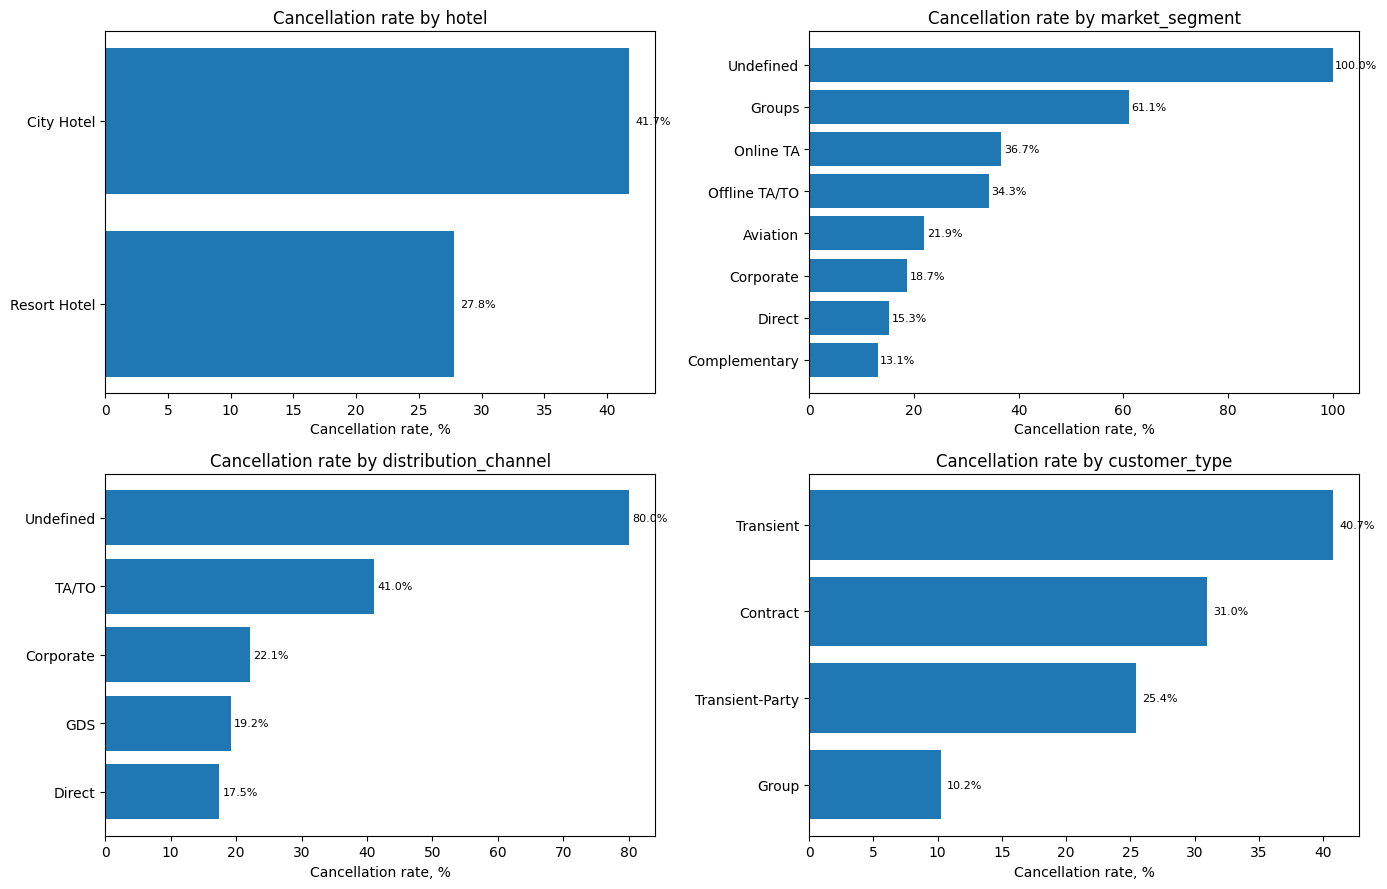

In [37]:
for col in ['hotel', 'market_segment', 'distribution_channel', 'customer_type']:
    tbl = rate_table(main_eda, col)
    tbl.to_csv(TABLES / f'hw4_rate_by_{col}.csv', index=False)
    display(Markdown(f'#### Cancellation rate by `{col}`'))
    display(tbl)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), ['hotel', 'market_segment', 'distribution_channel', 'customer_type']):
    tbl = rate_table(main_eda, col).sort_values('cancel_rate', ascending=True)
    ax.barh(tbl[col].astype(str), tbl['cancel_rate'] * 100)
    ax.set_title(f'Cancellation rate by {col}')
    ax.set_xlabel('Cancellation rate, %')
    for i, v in enumerate(tbl['cancel_rate'] * 100):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

savefig('hw4_cancellation_rates_by_core_categories.png')
plt.show()

**Вывод для моделирования.** Тип отеля, market segment, distribution channel и customer type дают заметно разные уровни отмен. Это базовые категориальные признаки для первой модели. Но редкие категории вроде `Undefined` нельзя переинтерпретировать как устойчивую закономерность: их надо либо объединять в `Other`, либо оставить модели как редкую категорию с регуляризацией.

### 3.5. Lead time как один из ключевых risk factors

,lead_time_bin,count,cancellations,cancel_rate,share_of_rows
0,0–7,19746,1902,0.0963,0.1654
1,8–30,18960,5283,0.2786,0.1588
2,31–90,29553,11141,0.3770,0.2475
3,91–180,26439,11821,0.4471,0.2215
4,181–365,21544,11947,0.5545,0.1805
5,366+,3148,2130,0.6766,0.0264


Saved: reports/figures/hw4_eda/hw4_lead_time_volume_and_rate.png


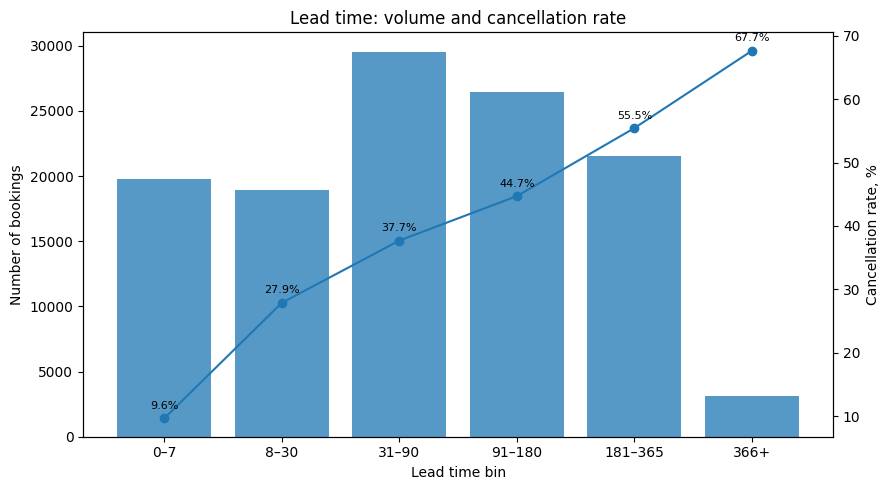

In [38]:
lead_tbl = rate_table(main_eda, 'lead_time_bin').sort_values('lead_time_bin')
lead_tbl.to_csv(TABLES / 'hw4_rate_by_lead_time_bin.csv', index=False)
display(lead_tbl)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(lead_tbl['lead_time_bin'].astype(str), lead_tbl['count'], alpha=0.75)
ax1.set_ylabel('Number of bookings')
ax1.set_xlabel('Lead time bin')
ax1.set_title('Lead time: volume and cancellation rate')

ax2 = ax1.twinx()
ax2.plot(lead_tbl['lead_time_bin'].astype(str), lead_tbl['cancel_rate'] * 100, marker='o')
ax2.set_ylabel('Cancellation rate, %')
for x, y in zip(lead_tbl['lead_time_bin'].astype(str), lead_tbl['cancel_rate'] * 100):
    ax2.text(x, y + 1.5, f'{y:.1f}%', ha='center', fontsize=8)

savefig('hw4_lead_time_volume_and_rate.png')
plt.show()

**Вывод для моделирования.** Чем больше срок до заезда, тем выше риск отмены. Это хорошо согласуется с продуктовой логикой: долгие ранние бронирования чаще меняются. `lead_time` должен быть обязательным числовым признаком, а `is_long_lead_booking` можно использовать как интерпретируемую бизнес-фичу.

### 3.6. Deposit type, special requests, repeated guest и parking spaces

Saved: reports/figures/hw4_eda/hw4_cancellation_rates_by_behavioral_factors.png


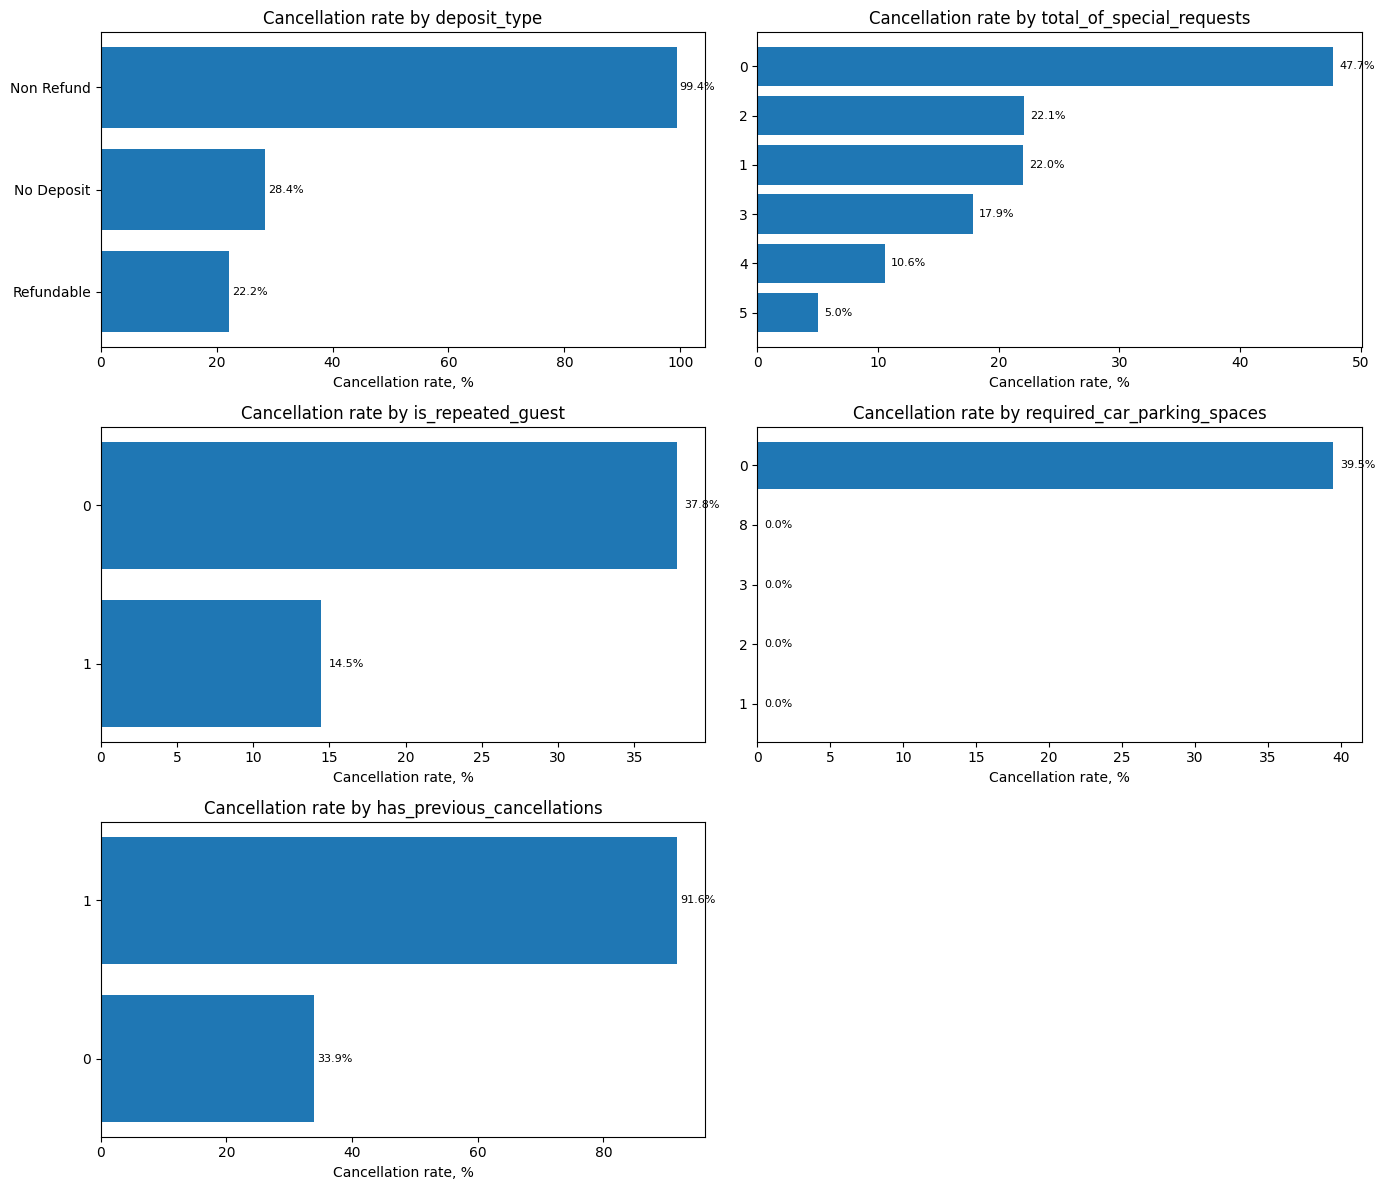

#### Cancellation rate by `deposit_type`

,deposit_type,count,cancellations,cancel_rate,share_of_rows
1,Non Refund,14587,14494,0.9936,0.1222
0,No Deposit,104641,29694,0.2838,0.8765
2,Refundable,162,36,0.2222,0.0014


#### Cancellation rate by `total_of_special_requests`

,total_of_special_requests,count,cancellations,cancel_rate,share_of_rows
0,0,70318,33556,0.4772,0.5890
2,2,12969,2866,0.2210,0.1086
1,1,33226,7318,0.2202,0.2783
3,3,2497,446,0.1786,0.0209
4,4,340,36,0.1059,0.0028
5,5,40,2,0.0500,0.0003


#### Cancellation rate by `is_repeated_guest`

,is_repeated_guest,count,cancellations,cancel_rate,share_of_rows
0,0,115580,43672,0.3779,0.9681
1,1,3810,552,0.1449,0.0319


#### Cancellation rate by `required_car_parking_spaces`

,required_car_parking_spaces,count,cancellations,cancel_rate,share_of_rows
0,0,111974,44224,0.3949,0.9379
1,1,7383,0,0.0000,0.0618
2,2,28,0,0.0000,0.0002
3,3,3,0,0.0000,0.0000
4,8,2,0,0.0000,0.0000


#### Cancellation rate by `has_previous_cancellations`

,has_previous_cancellations,count,cancellations,cancel_rate,share_of_rows
1,1,6484,5942,0.9164,0.0543
0,0,112906,38282,0.3391,0.9457


In [39]:
cols = ['deposit_type', 'total_of_special_requests', 'is_repeated_guest', 'required_car_parking_spaces', 'has_previous_cancellations']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    tbl = rate_table(main_eda, col).sort_values('cancel_rate', ascending=True)
    ax.barh(tbl[col].astype(str), tbl['cancel_rate'] * 100)
    ax.set_title(f'Cancellation rate by {col}')
    ax.set_xlabel('Cancellation rate, %')
    for i, v in enumerate(tbl['cancel_rate'] * 100):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
axes[-1].axis('off')
savefig('hw4_cancellation_rates_by_behavioral_factors.png')
plt.show()

for col in cols:
    display(Markdown(f'#### Cancellation rate by `{col}`'))
    display(rate_table(main_eda, col))

**Вывод для моделирования.** `deposit_type=Non Refund` почти детерминированно связан с отменой в этом датасете. Это не обязательно leakage, но это потенциально нестабильный бизнес-признак: в реальном отеле политика депозитов может отличаться. `total_of_special_requests` и `required_car_parking_spaces` выглядят как сильные behavioral-признаки: наличие запросов/парковки связано с меньшей вероятностью отмены. Эти признаки доступны на момент бронирования, поэтому их можно использовать, но нужно мониторить переносимость.

### 3.7. Сезонность и календарный профиль

,arrival_date_month,count,cancellations,cancel_rate,share_of_rows
4,January,5929,1807,0.3048,0.0497
3,February,8068,2696,0.3342,0.0676
7,March,9794,3149,0.3215,0.0820
0,April,11089,4524,0.4080,0.0929
8,May,11791,4677,0.3967,0.0988
6,June,10939,4535,0.4146,0.0916
5,July,12661,4742,0.3745,0.1060
1,August,13877,5239,0.3775,0.1162
11,September,10508,4116,0.3917,0.0880
10,October,11160,4246,0.3805,0.0935


Saved: reports/figures/hw4_eda/hw4_arrival_month_volume_and_rate.png


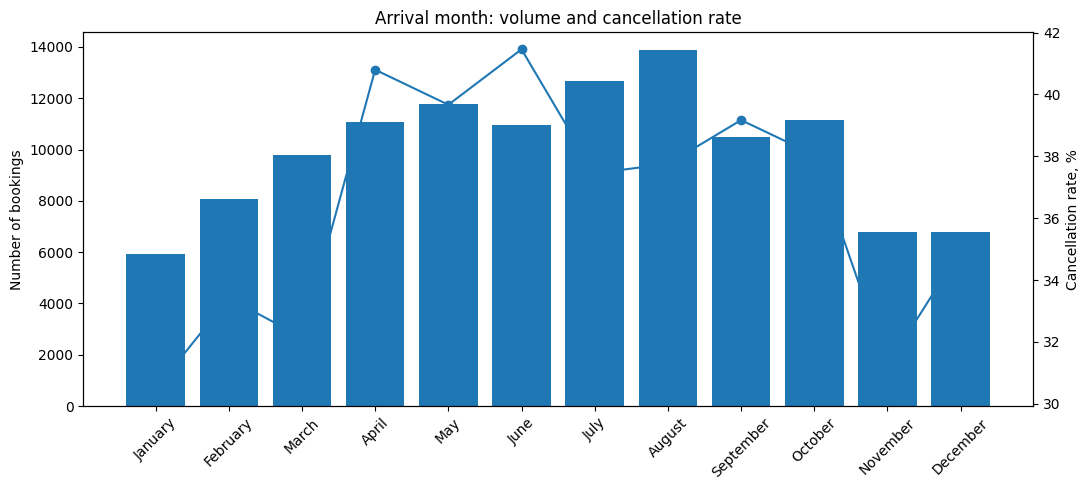

In [40]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_tbl = rate_table(main_eda, 'arrival_date_month')
month_tbl['arrival_date_month'] = pd.Categorical(month_tbl['arrival_date_month'], categories=month_order, ordered=True)
month_tbl = month_tbl.sort_values('arrival_date_month')
month_tbl.to_csv(TABLES / 'hw4_rate_by_arrival_month.csv', index=False)
display(month_tbl)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(month_tbl['arrival_date_month'].astype(str), month_tbl['count'])
ax1.set_ylabel('Number of bookings')
ax1.set_title('Arrival month: volume and cancellation rate')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(month_tbl['arrival_date_month'].astype(str), month_tbl['cancel_rate'] * 100, marker='o')
ax2.set_ylabel('Cancellation rate, %')
savefig('hw4_arrival_month_volume_and_rate.png')
plt.show()

Saved: reports/figures/hw4_eda/hw4_monthly_cancellation_rate_by_hotel.png


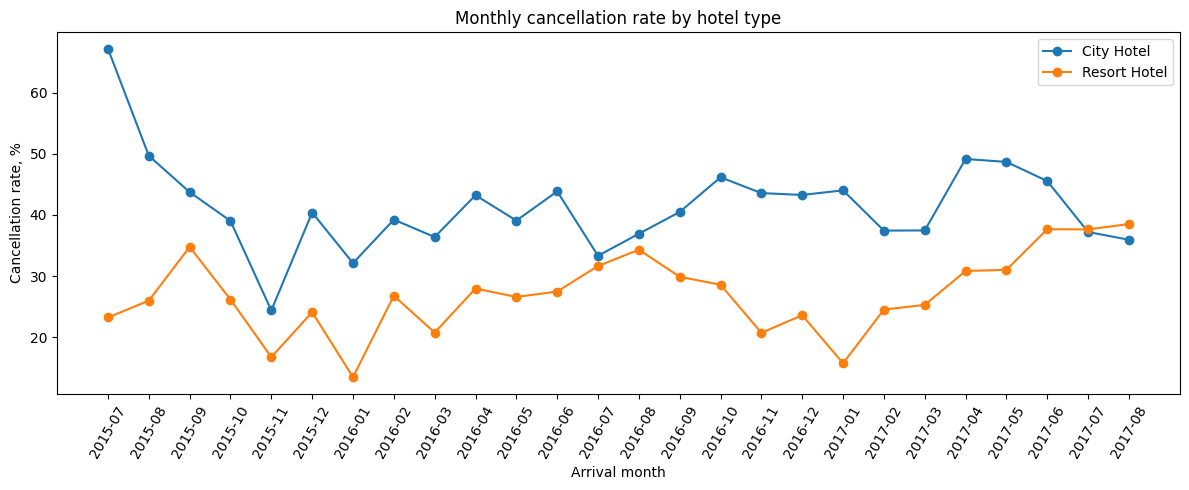

In [41]:
monthly = (
    main_eda.set_index('arrival_date')
    .groupby([pd.Grouper(freq='ME'), 'hotel'])['is_canceled']
    .agg(count='size', cancel_rate='mean')
    .reset_index()
)
monthly['month'] = monthly['arrival_date'].dt.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(12, 5))
for hotel, part in monthly.groupby('hotel'):
    ax.plot(part['month'], part['cancel_rate'] * 100, marker='o', label=hotel)
ax.set_title('Monthly cancellation rate by hotel type')
ax.set_ylabel('Cancellation rate, %')
ax.set_xlabel('Arrival month')
ax.tick_params(axis='x', rotation=60)
ax.legend()
savefig('hw4_monthly_cancellation_rate_by_hotel.png')
plt.show()

**Вывод для моделирования.** Есть календарные различия по месяцам и типам отеля. Для честной валидации это аргумент против random split: если перемешать периоды, модель увидит будущую сезонность в train. Поэтому основной split должен быть временным.

### 3.8. Heatmap: где концентрируется риск

Saved: reports/figures/hw4_eda/hw4_heatmap_market_segment_hotel.png


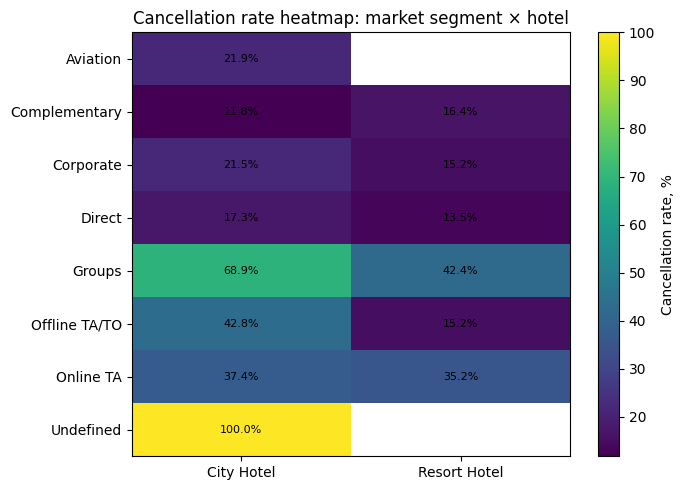

In [42]:
heat = pd.pivot_table(
    main_eda,
    values='is_canceled',
    index='market_segment',
    columns='hotel',
    aggfunc='mean'
).sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.values * 100, aspect='auto')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Cancellation rate heatmap: market segment × hotel')
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f'{value*100:.1f}%', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Cancellation rate, %')
savefig('hw4_heatmap_market_segment_hotel.png')
plt.show()

Saved: reports/figures/hw4_eda/hw4_heatmap_lead_time_deposit.png


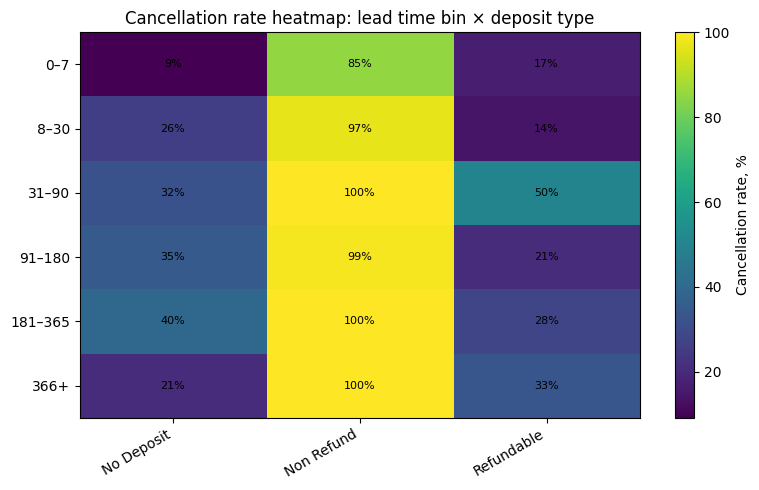

In [43]:
heat2 = pd.pivot_table(
    main_eda,
    values='is_canceled',
    index='lead_time_bin',
    columns='deposit_type',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat2.values * 100, aspect='auto')
ax.set_xticks(range(len(heat2.columns)))
ax.set_xticklabels(heat2.columns, rotation=30, ha='right')
ax.set_yticks(range(len(heat2.index)))
ax.set_yticklabels(heat2.index.astype(str))
ax.set_title('Cancellation rate heatmap: lead time bin × deposit type')
for i in range(len(heat2.index)):
    for j in range(len(heat2.columns)):
        value = heat2.values[i, j]
        if not np.isnan(value):
            ax.text(j, i, f'{value*100:.0f}%', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Cancellation rate, %')
savefig('hw4_heatmap_lead_time_deposit.png')
plt.show()

**Вывод для моделирования.** Риск отмены неоднороден: он формируется комбинацией признаков. Это объясняет, почему в дальнейшем нужен не только rule-based baseline, но и ML-модель, способная учитывать взаимодействия `lead_time × deposit_type × market_segment × hotel`.

### 3.9. Денежная фактура: booking value и revenue at risk

,market_segment,bookings,cancel_rate,total_booking_value,canceled_booking_value,mean_booking_value
6,Online TA,56477,0.3672,"23,942,047.5300","10,227,646.1100",423.9256
4,Groups,19810,0.6107,"4,669,700.5400","2,800,543.9800",235.7244
5,Offline TA/TO,24219,0.3432,"8,151,912.7300","2,492,358.1500",336.5916
3,Direct,12606,0.1534,"5,093,028.3900","993,409.8200",404.0162
2,Corporate,5295,0.1873,"774,295.2600","196,383.0700",146.2314
0,Aviation,237,0.2194,"87,446.3600","16,578.0000",368.9720
1,Complementary,743,0.1306,"5,082.5200",269.9900,6.8405
7,Undefined,2,1.0000,48.0000,48.0000,24.0000


Saved: reports/figures/hw4_eda/hw4_canceled_booking_value_by_segment.png


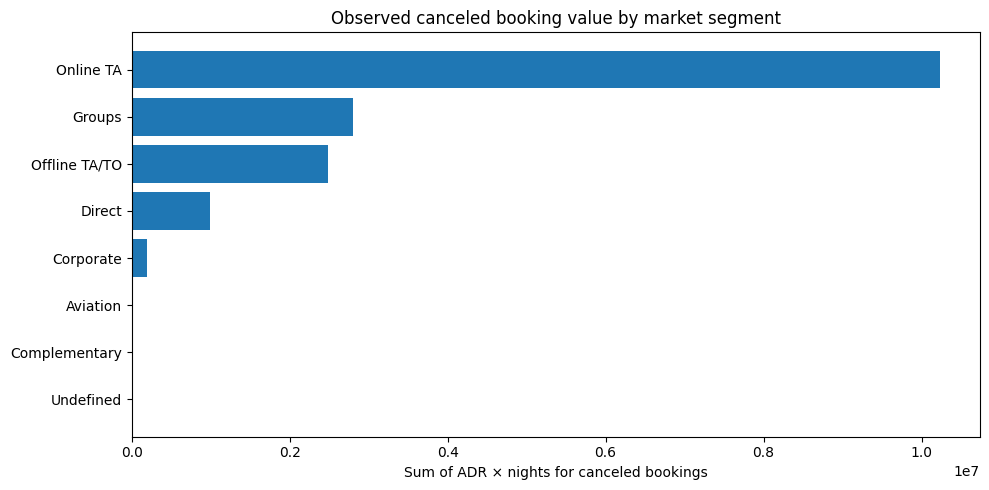

In [44]:
# Для денежного анализа берем только неотрицательные значения и ограничиваем экстремальные выбросы на графике.
money_df = main_eda[(main_eda['booking_value'] >= 0) & (main_eda['booking_value'].notna())].copy()

money_by_segment = (
    money_df.groupby('market_segment')
    .agg(
        bookings=('booking_id' if 'booking_id' in money_df.columns else 'is_canceled', 'size'),
        cancel_rate=('is_canceled', 'mean'),
        total_booking_value=('booking_value', 'sum'),
        canceled_booking_value=('booking_value', lambda s: s[money_df.loc[s.index, 'is_canceled'].eq(1)].sum()),
        mean_booking_value=('booking_value', 'mean'),
    )
    .reset_index()
    .sort_values('canceled_booking_value', ascending=False)
)
money_by_segment.to_csv(TABLES / 'hw4_revenue_at_risk_by_market_segment.csv', index=False)
display(money_by_segment)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = money_by_segment.sort_values('canceled_booking_value', ascending=True)
ax.barh(plot_df['market_segment'], plot_df['canceled_booking_value'])
ax.set_title('Observed canceled booking value by market segment')
ax.set_xlabel('Sum of ADR × nights for canceled bookings')
savefig('hw4_canceled_booking_value_by_segment.png')
plt.show()

**Вывод для продукта.** Моделирование должно сохранять признаки, необходимые для расчета денежного эффекта: `adr`, `total_nights`, `booking_value`. Даже если финальная ML-метрика высокая, продуктовая ценность появляется только когда top-risk список связан с потенциальной выручкой под риском.

## 4. Leakage audit

Для продукта важно зафиксировать момент прогноза:

```text
прогноз делается после создания бронирования, но до отмены/заезда/финального статуса
```

Значит, нельзя использовать признаки, которые становятся известны после исхода бронирования. Иначе модель покажет искусственно высокие метрики, но не будет применима в реальности.

### `reservation_status` полностью кодирует target

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


is_canceled,0,1
reservation_status,,
Canceled,0.0000,1.0000
Check-Out,1.0000,0.0000
No-Show,0.0000,1.0000


Saved: reports/figures/hw4_eda/hw4_leakage_reservation_status.png


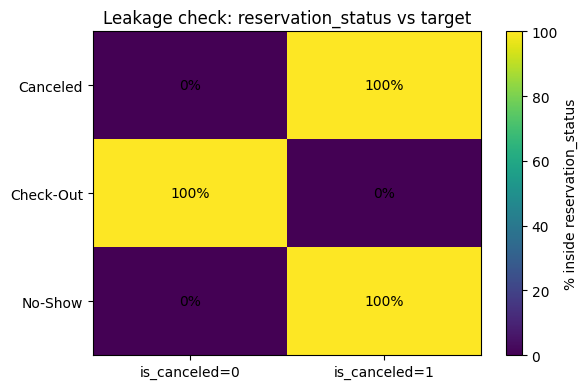

In [45]:
leakage_crosstab = pd.crosstab(main_eda['reservation_status'], main_eda['is_canceled'])
leakage_crosstab_norm = pd.crosstab(main_eda['reservation_status'], main_eda['is_canceled'], normalize='index')
display(Markdown('### `reservation_status` полностью кодирует target'))
display(leakage_crosstab)
display(leakage_crosstab_norm)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(leakage_crosstab_norm.values * 100, aspect='auto')
ax.set_xticks([0, 1])
ax.set_xticklabels(['is_canceled=0', 'is_canceled=1'])
ax.set_yticks(range(len(leakage_crosstab_norm.index)))
ax.set_yticklabels(leakage_crosstab_norm.index)
ax.set_title('Leakage check: reservation_status vs target')
for i in range(len(leakage_crosstab_norm.index)):
    for j in range(2):
        ax.text(j, i, f'{leakage_crosstab_norm.values[i, j]*100:.0f}%', ha='center', va='center')
fig.colorbar(im, ax=ax, label='% inside reservation_status')
savefig('hw4_leakage_reservation_status.png')
plt.show()

In [46]:
leakage_decision = pd.DataFrame([
    {'column': 'reservation_status', 'decision': 'exclude', 'reason': 'post-factum status; exactly determines target'},
    {'column': 'reservation_status_date', 'decision': 'exclude', 'reason': 'contains status/cancellation/check-out date; unavailable at prediction moment'},
    {'column': 'assigned_room_type', 'decision': 'exclude from first modeling dataset', 'reason': 'can be assigned or changed later; risk of operational leakage'},
    {'column': 'booking_changes', 'decision': 'exclude from first modeling dataset', 'reason': 'can happen after initial booking; not guaranteed at prediction moment'},
    {'column': 'days_in_waiting_list', 'decision': 'exclude from first modeling dataset', 'reason': 'may be known only after waiting-list process; keep for later sensitivity test'},
])
leakage_decision.to_csv(TABLES / 'hw4_leakage_audit.csv', index=False)
display(leakage_decision)

,column,decision,reason
0,reservation_status,exclude,post-factum status; exactly determines target
1,reservation_status_date,exclude,contains status/cancellation/check-out date; u...
2,assigned_room_type,exclude from first modeling dataset,can be assigned or changed later; risk of oper...
3,booking_changes,exclude from first modeling dataset,can happen after initial booking; not guarante...
4,days_in_waiting_list,exclude from first modeling dataset,may be known only after waiting-list process; ...


**Решение.** В итоговый modeling dataset не включаем `reservation_status`, `reservation_status_date`, `assigned_room_type`, `booking_changes`, `days_in_waiting_list`. Это консервативное решение: лучше получить чуть более низкую, но честную ML-метрику, чем переоценить качество из-за утечки.

## 5. Оценка качества разметки

Разметка не ручная, а событийная: `is_canceled=1`, если бронирование завершилось статусом `Canceled` или `No-Show`; `0`, если `Check-Out`. Это снижает риск субъективной разметки, но оставляет несколько ограничений.

In [47]:
label_quality = pd.DataFrame([
    {'aspect': 'label source', 'assessment': 'event log / reservation status, not manual annotation'},
    {'aspect': 'subjectivity', 'assessment': 'low: label is based on booking outcome'},
    {'aspect': 'ambiguity', 'assessment': 'medium: Canceled and No-Show are both mapped to is_canceled=1, but business actions may differ'},
    {'aspect': 'temporal leakage risk', 'assessment': 'high if reservation_status or reservation_status_date are used as features'},
    {'aspect': 'class balance', 'assessment': f"positive class rate = {main_eda['is_canceled'].mean():.2%}"},
    {'aspect': 'recommendation', 'assessment': 'keep binary target for first iteration; later split Canceled vs No-Show if real PMS data allows'},
])
display(label_quality)

status_counts = (
    main_eda.groupby(['reservation_status', 'is_canceled'])
    .size()
    .reset_index(name='count')
)
status_counts.to_csv(TABLES / 'hw4_label_status_consistency.csv', index=False)
display(status_counts)

,aspect,assessment
0,label source,"event log / reservation status, not manual ann..."
1,subjectivity,low: label is based on booking outcome
2,ambiguity,medium: Canceled and No-Show are both mapped t...
3,temporal leakage risk,high if reservation_status or reservation_stat...
4,class balance,positive class rate = 37.04%
5,recommendation,keep binary target for first iteration; later ...


,reservation_status,is_canceled,count
0,Canceled,1,43017
1,Check-Out,0,75166
2,No-Show,1,1207


**Предложения по повышению качества разметки для реального пилота:**

1. Разделить `Canceled` и `No-Show` на разные классы или хотя бы хранить отдельный флаг no-show.
2. Сохранять timestamp создания бронирования, timestamp отмены, канал отмены и штраф/депозит.
3. Разметить, была ли отмена поздней: например, менее чем за 1–3 дня до заезда.
4. Добавить бизнес-лейбл `avoidable_cancellation`, если действие менеджера могло повлиять на исход.
5. Собирать реальные результаты интервенций: отправили подтверждение → отменил/не отменил.

## 6. Алгоритм формирования итоговых датасетов

На выходе формируем три файла:

| Файл | Назначение |
|---|---|
| `data/processed/main_modeling_dataset.csv` | основной очищенный датасет для train/valid/test |
| `data/processed/additional_harmonized_dataset.csv` | дополнительный датасет, приведенный к общей схеме для external validation |
| `data/processed/combined_common_schema_dataset.csv` | объединенный датасет с `source_dataset`; использовать только для domain-aware экспериментов |

Ниже код подготовки данных полностью воспроизводим в ноутбуке.

In [48]:
def prepare_main_dataset(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['source_dataset'] = 'hotel_booking_demand'
    out['booking_id'] = np.arange(1, len(out) + 1)
    out['children'] = out['children'].fillna(0)
    out['arrival_month_num'] = out['arrival_date_month'].map(MONTHS)
    out['arrival_date'] = pd.to_datetime(dict(
        year=out['arrival_date_year'],
        month=out['arrival_month_num'],
        day=out['arrival_date_day_of_month'],
    ), errors='coerce')
    out['booking_creation_date'] = out['arrival_date'] - pd.to_timedelta(out['lead_time'], unit='D')
    out['total_nights'] = out['stays_in_weekend_nights'] + out['stays_in_week_nights']
    out['total_guests'] = out['adults'] + out['children'] + out['babies']
    out['has_children'] = ((out['children'] + out['babies']) > 0).astype(int)
    out['has_previous_cancellations'] = (out['previous_cancellations'] > 0).astype(int)
    out['has_special_requests'] = (out['total_of_special_requests'] > 0).astype(int)
    out['is_long_lead_booking'] = (out['lead_time'] > 90).astype(int)
    out['is_weekend_stay'] = (out['stays_in_weekend_nights'] > 0).astype(int)
    out['country_missing'] = out['country'].isna().astype(int)
    out['country'] = out['country'].fillna('Unknown')
    out['agent_missing'] = out['agent'].isna().astype(int)
    out['agent'] = out['agent'].fillna(0).astype(int).astype(str)
    out['has_company'] = out['company'].notna().astype(int)
    out['booking_value'] = out['adr'] * out['total_nights']
    out['arrival_season'] = out['arrival_month_num'].map(season)

    # Минимальная санитарная очистка.
    out = out[(out['total_guests'] > 0) & (out['total_nights'] > 0) & (out['adr'] >= 0) & out['arrival_date'].notna()].copy()

    # Time-based split по расчетной дате создания бронирования.
    out['split'] = np.select(
        [out['booking_creation_date'] <= pd.Timestamp('2016-10-31'),
         out['booking_creation_date'] <= pd.Timestamp('2017-03-31')],
        ['train', 'valid'],
        default='test'
    )

    allowed_cols = [
        'source_dataset','booking_id','split','hotel','is_canceled','lead_time','arrival_date','booking_creation_date',
        'arrival_date_year','arrival_month_num','arrival_date_month','arrival_date_week_number','arrival_date_day_of_month','arrival_season',
        'stays_in_weekend_nights','stays_in_week_nights','total_nights','adults','children','babies','total_guests','has_children',
        'meal','country','country_missing','market_segment','distribution_channel','is_repeated_guest','previous_cancellations',
        'previous_bookings_not_canceled','has_previous_cancellations','reserved_room_type','deposit_type','agent','agent_missing','has_company',
        'customer_type','adr','booking_value','required_car_parking_spaces','total_of_special_requests','has_special_requests','is_long_lead_booking','is_weekend_stay'
    ]
    return out[allowed_cols]


def prepare_additional_dataset(df: pd.DataFrame, columns_like: list[str]) -> pd.DataFrame:
    src = df.copy()
    src['is_canceled'] = (src['booking_status'] == 'Canceled').astype(int)
    src['arrival_date_dt'] = pd.to_datetime(dict(
        year=src['arrival_year'],
        month=src['arrival_month'],
        day=src['arrival_date'],
    ), errors='coerce')
    src['booking_creation_date'] = src['arrival_date_dt'] - pd.to_timedelta(src['lead_time'], unit='D')
    src['total_nights'] = src['no_of_weekend_nights'] + src['no_of_week_nights']
    src['total_guests'] = src['no_of_adults'] + src['no_of_children']
    src['has_children'] = (src['no_of_children'] > 0).astype(int)
    src['has_previous_cancellations'] = (src['no_of_previous_cancellations'] > 0).astype(int)
    src['has_special_requests'] = (src['no_of_special_requests'] > 0).astype(int)
    src['booking_value'] = src['avg_price_per_room'] * src['total_nights']

    out = pd.DataFrame({
        'source_dataset': 'hotel_reservations_classification',
        'booking_id': src['Booking_ID'],
        'split': 'external',
        'hotel': 'Unknown',
        'is_canceled': src['is_canceled'],
        'lead_time': src['lead_time'],
        'arrival_date': src['arrival_date_dt'],
        'booking_creation_date': src['booking_creation_date'],
        'arrival_date_year': src['arrival_year'],
        'arrival_month_num': src['arrival_month'],
        'arrival_date_month': src['arrival_month'].map(MONTHS_REV),
        'arrival_date_week_number': np.nan,
        'arrival_date_day_of_month': src['arrival_date'],
        'arrival_season': src['arrival_month'].map(season),
        'stays_in_weekend_nights': src['no_of_weekend_nights'],
        'stays_in_week_nights': src['no_of_week_nights'],
        'total_nights': src['total_nights'],
        'adults': src['no_of_adults'],
        'children': src['no_of_children'],
        'babies': 0,
        'total_guests': src['total_guests'],
        'has_children': src['has_children'],
        'meal': src['type_of_meal_plan'],
        'country': 'Unknown',
        'country_missing': 1,
        'market_segment': src['market_segment_type'],
        'distribution_channel': 'Unknown',
        'is_repeated_guest': src['repeated_guest'],
        'previous_cancellations': src['no_of_previous_cancellations'],
        'previous_bookings_not_canceled': src['no_of_previous_bookings_not_canceled'],
        'has_previous_cancellations': src['has_previous_cancellations'],
        'reserved_room_type': src['room_type_reserved'],
        'deposit_type': 'Unknown',
        'agent': 'Unknown',
        'agent_missing': 1,
        'has_company': 0,
        'customer_type': 'Unknown',
        'adr': src['avg_price_per_room'],
        'booking_value': src['booking_value'],
        'required_car_parking_spaces': src['required_car_parking_space'],
        'total_of_special_requests': src['no_of_special_requests'],
        'has_special_requests': src['has_special_requests'],
        'is_long_lead_booking': (src['lead_time'] > 90).astype(int),
        'is_weekend_stay': (src['no_of_weekend_nights'] > 0).astype(int),
    })
    out = out[(out['total_guests'] > 0) & (out['total_nights'] > 0) & (out['adr'] >= 0) & out['arrival_date'].notna()].copy()
    return out[columns_like]

main_dataset = prepare_main_dataset(main_raw)
additional_dataset = prepare_additional_dataset(extra_raw, list(main_dataset.columns))
combined_dataset = pd.concat([main_dataset, additional_dataset], ignore_index=True)

main_dataset.to_csv(DATA_PROCESSED / 'main_modeling_dataset.csv', index=False)
additional_dataset.to_csv(DATA_PROCESSED / 'additional_harmonized_dataset.csv', index=False)
combined_dataset.to_csv(DATA_PROCESSED / 'combined_common_schema_dataset.csv', index=False)

output_summary = pd.DataFrame([
    {'file': 'data/processed/main_modeling_dataset.csv', 'rows': len(main_dataset), 'columns': main_dataset.shape[1], 'cancel_rate': main_dataset['is_canceled'].mean()},
    {'file': 'data/processed/additional_harmonized_dataset.csv', 'rows': len(additional_dataset), 'columns': additional_dataset.shape[1], 'cancel_rate': additional_dataset['is_canceled'].mean()},
    {'file': 'data/processed/combined_common_schema_dataset.csv', 'rows': len(combined_dataset), 'columns': combined_dataset.shape[1], 'cancel_rate': combined_dataset['is_canceled'].mean()},
])
output_summary.to_csv(TABLES / 'hw4_processed_datasets_summary.csv', index=False)
display(output_summary)

,file,rows,columns,cancel_rate
0,data/processed/main_modeling_dataset.csv,118564,44,0.3726
1,data/processed/additional_harmonized_dataset.csv,36160,44,0.3284
2,data/processed/combined_common_schema_dataset.csv,154724,44,0.3623


## 7. Формирование train / validation / test и стратегия валидации

Random split для этой задачи нежелателен: бронирования имеют временную структуру, сезонность и сдвиги между периодами. Поэтому используем time-based split по расчетной дате создания брони.

- `train`: бронирования, созданные до 2016-10-31 включительно;
- `valid`: 2016-11-01 — 2017-03-31;
- `test`: после 2017-03-31.

Такой split имитирует реальный сценарий: модель учится на прошлом и проверяется на будущих заявках.

,split,rows,cancel_rate,min_creation_date,max_creation_date,total_booking_value
0,test,9252,0.2827,2017-04-01,2017-08-31,"4,287,434.5900"
1,train,82050,0.3824,2014-03-18,2016-10-31,"27,854,376.6000"
2,valid,27262,0.3735,2016-11-01,2017-03-31,"10,572,401.9600"


Saved: reports/figures/hw4_eda/hw4_split_summary.png


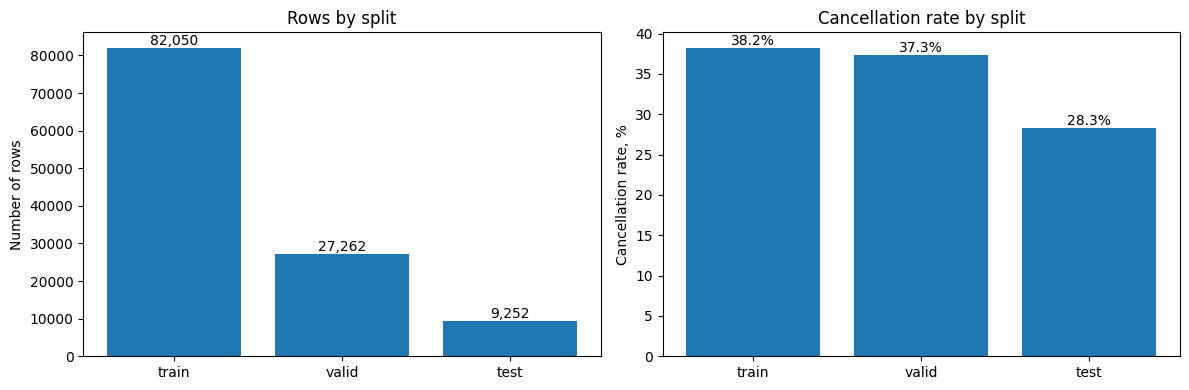

In [49]:
split_summary = (
    main_dataset.groupby('split')
    .agg(
        rows=('is_canceled', 'size'),
        cancel_rate=('is_canceled', 'mean'),
        min_creation_date=('booking_creation_date', 'min'),
        max_creation_date=('booking_creation_date', 'max'),
        total_booking_value=('booking_value', 'sum'),
    )
    .reset_index()
)
split_summary.to_csv(TABLES / 'hw4_split_summary.csv', index=False)
display(split_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ['train', 'valid', 'test']
plot_split = split_summary.set_index('split').loc[order].reset_index()
axes[0].bar(plot_split['split'], plot_split['rows'])
axes[0].set_title('Rows by split')
axes[0].set_ylabel('Number of rows')
for i, v in enumerate(plot_split['rows']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].bar(plot_split['split'], plot_split['cancel_rate'] * 100)
axes[1].set_title('Cancellation rate by split')
axes[1].set_ylabel('Cancellation rate, %')
for i, v in enumerate(plot_split['cancel_rate'] * 100):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

savefig('hw4_split_summary.png')
plt.show()

,split,hotel,count,cancel_rate
0,test,City Hotel,6048,0.2920
1,test,Resort Hotel,3204,0.2653
2,train,City Hotel,54250,0.4295
3,train,Resort Hotel,27800,0.2906
4,valid,City Hotel,18601,0.4301
5,valid,Resort Hotel,8661,0.2518


Saved: reports/figures/hw4_eda/hw4_split_cancellation_rate_by_hotel.png


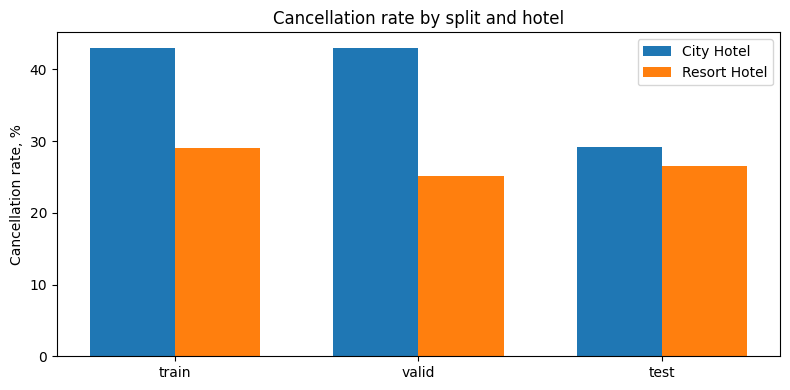

In [50]:
split_hotel = (
    main_dataset.groupby(['split', 'hotel'])['is_canceled']
    .agg(count='size', cancel_rate='mean')
    .reset_index()
)
split_hotel.to_csv(TABLES / 'hw4_split_by_hotel.csv', index=False)
display(split_hotel)

fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
x = np.arange(len(order))
for idx, hotel in enumerate(['City Hotel', 'Resort Hotel']):
    vals = split_hotel[split_hotel['hotel'] == hotel].set_index('split').loc[order]['cancel_rate'].values * 100
    ax.bar(x + (idx - 0.5) * width, vals, width, label=hotel)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title('Cancellation rate by split and hotel')
ax.set_ylabel('Cancellation rate, %')
ax.legend()
savefig('hw4_split_cancellation_rate_by_hotel.png')
plt.show()

**Вывод для валидации.** Test period имеет более низкую долю отмен, чем train/valid. Это не ошибка, а полезная проверка устойчивости: модель не должна полагаться только на стабильность base rate. В следующем ДЗ при оценке моделей нужно обязательно смотреть ranking-метрики и калибровку вероятностей.

## 8. Дополнительный датасет как external validation

Дополнительный датасет приведен к общей схеме, но не является полным аналогом основного. В нем нет типа отеля, страны, типа депозита, distribution channel, customer type и ряда операционных признаков. Поэтому его роль — внешняя проверка ограниченного набора признаков, а не механическое увеличение train.

,dataset,rows,cancel_rate,date_min,date_max
0,main processed,118564,0.3726,2015-07-01,2017-08-31
1,additional harmonized,36160,0.3284,2017-07-01,2018-12-31


,source,lead_time_bin,count,cancel_rate
0,hotel_booking_demand,0–7,19246,0.0973
1,hotel_booking_demand,8–30,18848,0.2800
2,hotel_booking_demand,31–90,29437,0.3783
3,hotel_booking_demand,91–180,26384,0.4479
4,hotel_booking_demand,181–365,21505,0.5553
5,hotel_booking_demand,366+,3144,0.6772
6,hotel_reservations_classification,0–7,5757,0.0893
7,hotel_reservations_classification,8–30,6586,0.1893
8,hotel_reservations_classification,31–90,10788,0.2530
9,hotel_reservations_classification,91–180,7758,0.4497


Saved: reports/figures/hw4_eda/hw4_external_validation_lead_time.png


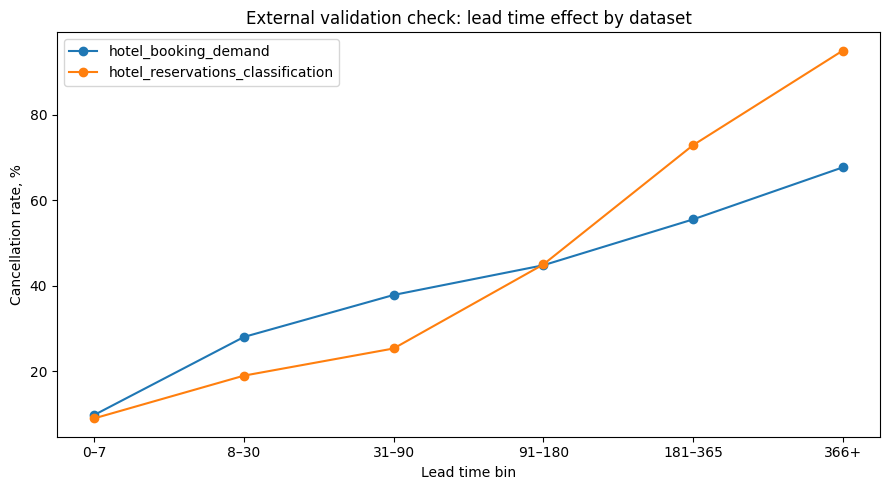

In [51]:
external_comparison = pd.DataFrame([
    {'dataset': 'main processed', 'rows': len(main_dataset), 'cancel_rate': main_dataset['is_canceled'].mean(), 'date_min': main_dataset['arrival_date'].min(), 'date_max': main_dataset['arrival_date'].max()},
    {'dataset': 'additional harmonized', 'rows': len(additional_dataset), 'cancel_rate': additional_dataset['is_canceled'].mean(), 'date_min': additional_dataset['arrival_date'].min(), 'date_max': additional_dataset['arrival_date'].max()},
])
external_comparison.to_csv(TABLES / 'hw4_external_dataset_comparison.csv', index=False)
display(external_comparison)

# Сравнение по общим признакам: lead_time_bin и special requests.
main_tmp = main_dataset.copy()
add_tmp = additional_dataset.copy()
for d in [main_tmp, add_tmp]:
    d['lead_time_bin'] = pd.cut(d['lead_time'], bins=[-1, 7, 30, 90, 180, 365, 1000], labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+'])
    d['source'] = d['source_dataset'].iloc[0]
compare_lead = pd.concat([main_tmp, add_tmp], ignore_index=True).groupby(['source', 'lead_time_bin'], observed=False)['is_canceled'].agg(count='size', cancel_rate='mean').reset_index()
display(compare_lead)

fig, ax = plt.subplots(figsize=(9, 5))
for source, part in compare_lead.groupby('source'):
    ax.plot(part['lead_time_bin'].astype(str), part['cancel_rate'] * 100, marker='o', label=source)
ax.set_title('External validation check: lead time effect by dataset')
ax.set_xlabel('Lead time bin')
ax.set_ylabel('Cancellation rate, %')
ax.legend()
savefig('hw4_external_validation_lead_time.png')
plt.show()

**Вывод по external validation.** Эффект `lead_time` качественно сохраняется: более длинный срок до заезда связан с более высокой долей отмен. Но различия в схеме и периоде данных означают, что дополнительный датасет нельзя просто добавлять в train без контроля доменного сдвига.

## 9. Финальный список признаков для следующего этапа моделирования

**Target:** `is_canceled`.

**Обязательные признаки первой модели:**

- числовые: `lead_time`, `total_nights`, `total_guests`, `adr`, `booking_value`, `previous_cancellations`, `previous_bookings_not_canceled`, `total_of_special_requests`, `required_car_parking_spaces`;
- бинарные: `is_repeated_guest`, `has_children`, `has_previous_cancellations`, `has_special_requests`, `is_long_lead_booking`, `is_weekend_stay`, `country_missing`, `agent_missing`, `has_company`;
- категориальные: `hotel`, `arrival_date_month`, `arrival_season`, `meal`, `country`, `market_segment`, `distribution_channel`, `reserved_room_type`, `deposit_type`, `agent`, `customer_type`.

**Исключаем из первой модели:**

- `reservation_status`, `reservation_status_date` — прямой post-factum leakage;
- `assigned_room_type`, `booking_changes`, `days_in_waiting_list` — операционные признаки с риском доступности после момента прогноза;
- `company` как сырой ID — слишком много пропусков; оставляем `has_company`.

In [52]:
final_feature_groups = {
    'target': ['is_canceled'],
    'numeric_features': ['lead_time','total_nights','total_guests','adr','booking_value','previous_cancellations','previous_bookings_not_canceled','total_of_special_requests','required_car_parking_spaces'],
    'binary_features': ['is_repeated_guest','has_children','has_previous_cancellations','has_special_requests','is_long_lead_booking','is_weekend_stay','country_missing','agent_missing','has_company'],
    'categorical_features': ['hotel','arrival_date_month','arrival_season','meal','country','market_segment','distribution_channel','reserved_room_type','deposit_type','agent','customer_type'],
    'excluded_leakage_or_unstable': ['reservation_status','reservation_status_date','assigned_room_type','booking_changes','days_in_waiting_list','company'],
}
for group, cols in final_feature_groups.items():
    display(Markdown(f'### {group}'))
    display(pd.DataFrame({'column': cols}))

### target

,column
0,is_canceled


### numeric_features

,column
0,lead_time
1,total_nights
2,total_guests
3,adr
4,booking_value
5,previous_cancellations
6,previous_bookings_not_canceled
7,total_of_special_requests
8,required_car_parking_spaces


### binary_features

,column
0,is_repeated_guest
1,has_children
2,has_previous_cancellations
3,has_special_requests
4,is_long_lead_booking
5,is_weekend_stay
6,country_missing
7,agent_missing
8,has_company


### categorical_features

,column
0,hotel
1,arrival_date_month
2,arrival_season
3,meal
4,country
5,market_segment
6,distribution_channel
7,reserved_room_type
8,deposit_type
9,agent


### excluded_leakage_or_unstable

,column
0,reservation_status
1,reservation_status_date
2,assigned_room_type
3,booking_changes
4,days_in_waiting_list
5,company


## 10. Итог ДЗ №4

Сформирован датасет для решения задачи прогнозирования отмен бронирований.

**Что сделано:**

1. Загружены и описаны два источника данных.
2. Проведен EDA с таблицами и визуализациями: target distribution, пропуски, выбросы, сегменты, lead time, сезонность, бизнес-стоимость отмен.
3. Проведен leakage audit: доказано, что `reservation_status` полностью кодирует target; опасные признаки исключены.
4. Оценено качество разметки: метка событийная, не ручная, но объединяет Canceled и No-Show.
5. Сформирован основной modeling dataset и дополнительный harmonized dataset.
6. Зафиксирована стратегия time-based validation и роль external validation.

**Главное решение:** в следующих домашних заданиях модель должна оптимизироваться не под accuracy, а под честную способность ранжировать риск отмен: ROC-AUC/PR-AUC + Precision@K/Recall@K/Lift@K + Expected Revenue at Risk.